# ITT Pulmon de Oriente - Seguridad T1 2026, Cali

## Version parcial de seguridad

- Zona agregada: Pulmon de Oriente
- Corte principal: primer trimestre de 2026
- Dimension implementada: Seguridad
- Indicadores: Homicidios y Hurtos
- Nota metodologica: el dato de homicidios T1 2026 se estima con el promedio observado de T1 2023-2025 mientras llega el dato oficial


## Celda 1 - Instalacion de dependencias


In [1]:
# Descomentar en Colab
!pip install geopandas pyproj shapely openpyxl matplotlib seaborn folium -q


## Celda 2 - Importaciones y configuracion


In [2]:
import os
import zipfile
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import folium

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)

sns.set_theme(style='whitegrid')
BG = '#F7F7F5'
COL_2023 = '#42A5F5'
COL_2024 = '#1B4F8A'
COL_2025 = '#E53935'
COL_2026 = '#2E7D32'
COLORS = {2023: COL_2023, 2024: COL_2024, 2025: COL_2025, 2026: COL_2026}


## Celda 3A - Subida ZIP (Colab)


In [4]:
# Ejecutar solo en Colab si necesitas subir el ZIP desde tu PC
try:
    from google.colab import files
    print('Selecciona Pulmon_De_Oriente_2026.zip...')
    uploaded = files.upload()
    if uploaded:
        zip_name = next(iter(uploaded.keys()))
        out_dir = '/content/Pulmon_De_Oriente_2026'
        os.makedirs(out_dir, exist_ok=True)
        with zipfile.ZipFile(zip_name, 'r') as zf:
            zf.extractall(out_dir)
        print(f'ZIP extraido en: {out_dir}')
except Exception as e:
    print('Celda opcional fuera de Colab:', e)


Selecciona Pulmon_De_Oriente_2026.zip...


Saving Pulmon_De_Oriente_2026.zip to Pulmon_De_Oriente_2026.zip
ZIP extraido en: /content/Pulmon_De_Oriente_2026


## Celda 3 - Parametros, rutas y umbrales

Se usan refs trimestrales provisionales calibrados para esta salida parcial de seguridad.


In [10]:
import os
import glob

# ============================================================
# Celda 3 - Parámetros, rutas y umbrales
# ============================================================

# Carpeta raíz donde Colab deja los archivos cargados/descomprimidos
ROOT = "/content"

# Buscar todos los archivos dentro de /content
ALL_FILES = [
    p for p in glob.glob(os.path.join(ROOT, "**", "*"), recursive=True)
    if os.path.isfile(p)
]

def buscar_archivo(nombres_exactos=None, contiene=None, extensiones=None):
    """
    Busca archivos dentro de /content.
    Permite buscar por nombre exacto o por palabras contenidas en el nombre.
    """
    nombres_exactos = nombres_exactos or []
    contiene = contiene or []
    extensiones = extensiones or []

    # 1. Buscar por nombre exacto
    for p in ALL_FILES:
        nombre = os.path.basename(p).lower()
        if nombre in [n.lower() for n in nombres_exactos]:
            return p

    # 2. Buscar por palabras contenidas
    for p in ALL_FILES:
        nombre = os.path.basename(p).lower()

        cumple_contenido = all(c.lower() in nombre for c in contiene)
        cumple_extension = True

        if extensiones:
            cumple_extension = any(nombre.endswith(ext.lower()) for ext in extensiones)

        if cumple_contenido and cumple_extension:
            return p

    return None


PATHS = {
    "zona": buscar_archivo(
        nombres_exactos=["poligonos_oriente.shp"],
        contiene=["poligonos", "oriente"],
        extensiones=[".shp"]
    ),

    "homicidios_t1": buscar_archivo(
        nombres_exactos=[
            "DATIC_homicidios_2023_2026T1_Pulmon_O.geojson",
            "DATT_homicidios_2023_2026T1_Pulmon_O.geojson"
        ],
        contiene=["homicidios", "2026"],
        extensiones=[".geojson", ".json", ".shp"]
    ),

    "hurtos_t1": buscar_archivo(
        nombres_exactos=[
            "DATIC_hurtos_2023_2026T1_Pulmon_O.geojson",
            "DATT_hurtos_2023_2026T1_Pulmon_O.geojson"
        ],
        contiene=["hurtos", "2026"],
        extensiones=[".geojson", ".json", ".shp"]
    )
}

# Años de análisis
ANIOS_HIST = [2023, 2024, 2025]
ANO_OBJ = 2026
ANIOS_SERIE = ANIOS_HIST + [ANO_OBJ]
TRIMESTRE_OBJ = 1

# Umbrales trimestrales provisionales para esta salida parcial
REFS = {
    "homicidios": (15.0, 30.0, True),
    "hurtos": (250.0, 1300.0, True),
}

# Archivo de salida
EXPORT_PATH = "ITT_Pulmon_Oriente_Seguridad_T1_2026.xlsx"

# Diagnóstico visual
print("Archivos detectados:")
for k, v in PATHS.items():
    print(f"{k}: {v}")

print("\nTotal de archivos encontrados en /content:", len(ALL_FILES))


Archivos detectados:
zona: None
homicidios_t1: /content/Pulmon_De_Oriente_2026/Pulmon_De_Oriente_2026/DATIC_homicidios_2023_2026T1_Pulmon_O.geojson
hurtos_t1: /content/Pulmon_De_Oriente_2026/Pulmon_De_Oriente_2026/DATIC_hurtos_2023_2026T1_Pulmon_O.geojson

Total de archivos encontrados en /content: 15


## Celda 4 - Carga de datos


In [12]:


def validar_rutas(paths):
    """
    Valida las rutas obligatorias.
    La zona se toma como opcional porque los archivos ya parecen venir
    recortados para Pulmon_O.
    """

    obligatorias = ["homicidios_t1", "hurtos_t1"]
    faltantes = []

    for k in obligatorias:
        v = paths.get(k)
        if v is None or not os.path.exists(v):
            faltantes.append(k)

    if faltantes:
        print("No se encontraron estas rutas obligatorias:")
        for f in faltantes:
            print(f"- {f}: {paths.get(f)}")

        print("\nArchivos disponibles encontrados en /content:")
        for archivo in ALL_FILES:
            print("-", archivo)

        raise FileNotFoundError(f"No se encontraron estas rutas obligatorias: {faltantes}")

    if paths.get("zona") is None:
        print("Advertencia: no se encontró archivo de zona.")
        print("Se continuará sin filtro espacial porque los archivos parecen venir como Pulmon_O.")
    else:
        print("Archivo de zona encontrado:", paths["zona"])

    print("Rutas obligatorias encontradas correctamente.")


def estandarizar_columnas(gdf):
    gdf = gdf.copy()
    gdf.columns = [str(c).strip().lower() for c in gdf.columns]
    return gdf


def pick_col(df, candidatos, requerido=True):
    cols = set(df.columns)

    for c in candidatos:
        if c in cols:
            return c

    if requerido:
        raise KeyError(f"No se encontró ninguna columna entre: {candidatos}")

    return None


def to_wgs(gdf):
    if gdf is None:
        return None

    if gdf.crs is None:
        gdf = gdf.set_crs(epsg=4326)

    return gdf.to_crs(epsg=4326)


def cargar_zona(paths):
    """
    Carga el polígono de zona si existe.
    Si no existe, retorna None para continuar sin filtro espacial.
    """

    zona_path = paths.get("zona")

    if zona_path is None or not os.path.exists(zona_path):
        return None

    gdf_zona = gpd.read_file(zona_path)
    gdf_zona = estandarizar_columnas(gdf_zona)
    gdf_zona = to_wgs(gdf_zona)
    gdf_zona = gdf_zona[["geometry"]].dissolve().reset_index(drop=True)

    return gdf_zona


def limpiar_duplicados_geograficos(gdf):
    """
    Limpieza básica de duplicados.
    Se aplica sobre todas las columnas no geométricas disponibles.
    """

    if gdf is None or len(gdf) == 0:
        return gdf

    gdf = gdf.copy()

    columnas_no_geom = [c for c in gdf.columns if c != "geometry"]

    if columnas_no_geom:
        gdf = gdf.drop_duplicates(subset=columnas_no_geom)

    return gdf


def filtrar_en_zona(gdf_eventos, gdf_zona):
    """
    Filtra eventos dentro del polígono.
    Si no hay zona, retorna los eventos sin filtrar.
    """

    if gdf_eventos is None:
        return None

    gdf_eventos = gdf_eventos[gdf_eventos.geometry.notna()].copy()

    if gdf_zona is None or len(gdf_zona) == 0:
        print("Sin polígono de zona: se omite filtro espacial.")
        return gdf_eventos

    zona = gdf_zona[["geometry"]].copy()

    filtrado = gpd.sjoin(
        gdf_eventos,
        zona,
        how="inner",
        predicate="within"
    )

    return filtrado.drop(columns=["index_right"], errors="ignore")


# Validar rutas
validar_rutas(PATHS)

# Cargar zona si existe
gdf_zona = cargar_zona(PATHS)

# Cargar homicidios
gdf_homicidios = gpd.read_file(PATHS["homicidios_t1"])
gdf_homicidios = estandarizar_columnas(gdf_homicidios)
gdf_homicidios = to_wgs(gdf_homicidios)
gdf_homicidios = limpiar_duplicados_geograficos(gdf_homicidios)
gdf_homicidios = filtrar_en_zona(gdf_homicidios, gdf_zona)

# Cargar hurtos
gdf_hurtos = gpd.read_file(PATHS["hurtos_t1"])
gdf_hurtos = estandarizar_columnas(gdf_hurtos)
gdf_hurtos = to_wgs(gdf_hurtos)
gdf_hurtos = limpiar_duplicados_geograficos(gdf_hurtos)
gdf_hurtos = filtrar_en_zona(gdf_hurtos, gdf_zona)

# Resultados de control
print("Zona cargada:", "Sí" if gdf_zona is not None else "No")
print("Homicidios 2023-2026 T1 cargados:", len(gdf_homicidios))
print("Hurtos 2023-2026 T1 cargados:", len(gdf_hurtos))

print("\nColumnas homicidios:")
print(list(gdf_homicidios.columns))

print("\nColumnas hurtos:")
print(list(gdf_hurtos.columns))

Advertencia: no se encontró archivo de zona.
Se continuará sin filtro espacial porque los archivos parecen venir como Pulmon_O.
Rutas obligatorias encontradas correctamente.


Sin polígono de zona: se omite filtro espacial.
Sin polígono de zona: se omite filtro espacial.
Zona cargada: No
Homicidios 2023-2026 T1 cargados: 313
Hurtos 2023-2026 T1 cargados: 4274

Columnas homicidios:
['no', 'semana', 'identifica', 'spoa', 'spoa_compl', 'direccion', 'barrio', 'comuna', 'idcombar', 'cuadrante', 'tipo_de_ar', 'tipo_ident', 'ocupacion', 'sexo', 'edad', 'fechao', 'fechah', 'diasem', 'jornadarh8', 'est28xrang', 'fh8', 'est32xdian', 'diasanio', 'fecham', 'fechai', 'lugar_hech', 'nom_lugar_', 'inspeccion', 'direcion_d', 'barrio_res', 'comuna_res', 'levantamie', 'estado_civ', 'escolarida', 'tipo_viole', 'categoria_', 'categori_1', 'subcategor', 'tipo_agres', 'jornada', 'fec_especi', 'x', 'y', 'feminicidi', 'procedimie', 'poblacion_', 'clasificac', 'barrioplan', 'estratopla', 'semanaexce', 'semanalund', 'semanacons', 'semanaco_1', 'finsemanac', 'multiples', 'agresor_en', 'genero', 'orientacio', 'manera_mue', 'nacionalid', 'sector', 'otra_nacio', 'ancestro', 'licor', 'dro

## Celda 5 - Mapa de geolocalizacion


In [27]:


import folium
import pandas as pd
import numpy as np
import geopandas as gpd

# Cambia a False si quieres ver todos los años disponibles
FILTRAR_SOLO_T1_2026 = True


def obtener_centro_mapa(gdf_zona=None, capas_eventos=None):
    """
    Obtiene centro del mapa.
    Prioridad:
    1. Polígono de zona.
    2. Eventos disponibles.
    3. Centro general de Cali.
    """

    if gdf_zona is not None and len(gdf_zona) > 0:
        zona_proj = gdf_zona.to_crs(epsg=3116)
        centro_proj = zona_proj.geometry.centroid.iloc[0]
        centro = gpd.GeoSeries([centro_proj], crs=3116).to_crs(epsg=4326).iloc[0]
        return [centro.y, centro.x], 15

    if capas_eventos:
        puntos = []

        for gdf in capas_eventos:
            if gdf is not None and len(gdf) > 0:
                tmp = gdf[gdf.geometry.notna()].copy()
                tmp = tmp.to_crs(epsg=4326)

                for geom in tmp.geometry:
                    if geom is None or geom.is_empty:
                        continue

                    if geom.geom_type == "Point":
                        puntos.append(geom)
                    else:
                        puntos.append(geom.representative_point())

        if puntos:
            gs = gpd.GeoSeries(puntos, crs=4326)
            minx, miny, maxx, maxy = gs.total_bounds
            return [(miny + maxy) / 2, (minx + maxx) / 2], 15

    return [3.4516, -76.5320], 12


def obtener_columna(df, candidatos):
    """
    Busca una columna entre varios posibles nombres.
    """

    cols = list(df.columns)
    cols_lower = {str(c).lower(): c for c in cols}

    for c in candidatos:
        if c.lower() in cols_lower:
            return cols_lower[c.lower()]

    return None


def preparar_fecha_eventos(gdf):
    """
    Crea columnas fecha_tmp, ano_tmp, mes_tmp y trimestre_tmp.
    """

    df = gdf.copy()

    fecha_col = obtener_columna(
        df,
        [
            "fecha_hech",
            "fecha_hecho",
            "fecha",
            "fechah",
            "fechao",
            "FECHA_HECH",
            "FECHA_HECHO",
            "Fecha"
        ]
    )

    if fecha_col is not None:
        df["fecha_tmp"] = pd.to_datetime(
            df[fecha_col],
            errors="coerce",
            dayfirst=True
        )
    else:
        df["fecha_tmp"] = pd.NaT

    df["ano_tmp"] = df["fecha_tmp"].dt.year
    df["mes_tmp"] = df["fecha_tmp"].dt.month

    ano_col = obtener_columna(df, ["anio", "ano", "año", "ANIO", "AÑO"])
    mes_col = obtener_columna(df, ["mes", "mes_num", "month", "MES"])

    if ano_col is not None:
        ano_num = pd.to_numeric(
            df[ano_col].astype(str).str.replace(",", ".", regex=False),
            errors="coerce"
        )
        df.loc[ano_num.notna(), "ano_tmp"] = ano_num[ano_num.notna()].astype(int)

    if mes_col is not None:
        mes_num = pd.to_numeric(
            df[mes_col].astype(str).str.replace(",", ".", regex=False),
            errors="coerce"
        )
        df.loc[mes_num.notna(), "mes_tmp"] = mes_num[mes_num.notna()].astype(int)

    df["trimestre_tmp"] = np.where(
        df["mes_tmp"].notna(),
        "T" + (((df["mes_tmp"].astype(float) - 1) // 3) + 1).astype("Int64").astype(str),
        None
    )

    return df


def filtrar_t1_2026(gdf):
    """
    Filtra eventos de enero a marzo de 2026.
    """

    df = preparar_fecha_eventos(gdf)

    if not FILTRAR_SOLO_T1_2026:
        return df

    df = df[
        (df["ano_tmp"] == 2026) &
        (df["mes_tmp"].between(1, 3))
    ].copy()

    return df


def obtener_punto(row):
    """
    Obtiene coordenadas desde geometría o desde columnas X/Y, lon/lat.
    Retorna [lat, lon].
    """

    geom = row.geometry

    if geom is not None and not geom.is_empty:
        if geom.geom_type == "Point":
            return [geom.y, geom.x]

        punto = geom.representative_point()
        return [punto.y, punto.x]

    # Respaldo por columnas
    posibles_lon = ["x", "lon", "longitud", "longitude", "LON", "X"]
    posibles_lat = ["y", "lat", "latitud", "latitude", "LAT", "Y"]

    lon_col = obtener_columna(pd.DataFrame([row]), posibles_lon)
    lat_col = obtener_columna(pd.DataFrame([row]), posibles_lat)

    if lon_col is not None and lat_col is not None:
        lon = row.get(lon_col)
        lat = row.get(lat_col)

        if pd.notna(lon) and pd.notna(lat):
            return [float(lat), float(lon)]

    return None


def texto_popup(row, nombre_indicador):
    """
    Construye popup informativo.
    """

    fecha_col = obtener_columna(
        pd.DataFrame([row]),
        ["fecha_hech", "fecha_hecho", "fecha", "fechah", "fechao", "FECHA_HECH"]
    )

    barrio_col = obtener_columna(
        pd.DataFrame([row]),
        ["nom_barrio", "barrio", "nombre_barrio", "NOM_BARRIO"]
    )

    direccion_col = obtener_columna(
        pd.DataFrame([row]),
        ["direccion", "dir", "DIRECCION"]
    )

    modalidad_col = obtener_columna(
        pd.DataFrame([row]),
        ["modalidad", "conducta", "delito", "descripcion", "MODALIDAD"]
    )

    fecha = str(row.get(fecha_col, ""))[:10] if fecha_col else ""
    barrio = row.get(barrio_col, "") if barrio_col else ""
    direccion = row.get(direccion_col, "") if direccion_col else ""
    modalidad = row.get(modalidad_col, "") if modalidad_col else ""

    return (
        f"<b>{nombre_indicador}</b><br>"
        f"<b>Fecha:</b> {fecha}<br>"
        f"<b>Barrio:</b> {barrio}<br>"
        f"<b>Dirección:</b> {direccion}<br>"
        f"<b>Modalidad:</b> {modalidad}"
    )


def agregar_capa_seguridad(mapa, gdf, nombre, color, icono):
    """
    Agrega una capa de eventos de seguridad al mapa.
    """

    fg = folium.FeatureGroup(name=nombre, show=True)

    total = 0

    for _, row in gdf.iterrows():
        punto = obtener_punto(row)

        if punto is None:
            continue

        popup = folium.Popup(
            texto_popup(row, nombre),
            max_width=320
        )

        folium.Marker(
            location=punto,
            popup=popup,
            icon=folium.Icon(
                color=color,
                icon=icono,
                prefix="glyphicon"
            )
        ).add_to(fg)

        total += 1

    fg.add_to(mapa)

    return total


# ============================================================
# Preparar capas
# ============================================================

gdf_homicidios_mapa = filtrar_t1_2026(gdf_homicidios)
gdf_hurtos_mapa = filtrar_t1_2026(gdf_hurtos)

location, zoom = obtener_centro_mapa(
    gdf_zona,
    capas_eventos=[gdf_homicidios_mapa, gdf_hurtos_mapa]
)

m = folium.Map(
    location=location,
    zoom_start=zoom,
    tiles="CartoDB positron"
)


# ============================================================
# Agregar polígono de zona si existe
# ============================================================

if gdf_zona is not None and len(gdf_zona) > 0:
    folium.GeoJson(
        gdf_zona.__geo_interface__,
        name="Pulmón de Oriente",
        style_function=lambda x: {
            "fillColor": "#F9A825",
            "color": "#1B4F8A",
            "weight": 2,
            "fillOpacity": 0.10
        }
    ).add_to(m)
else:
    print("No se encontró polígono de zona. El mapa se centrará con los eventos.")


# ============================================================
# Agregar capas de seguridad
# ============================================================

total_homicidios = agregar_capa_seguridad(
    mapa=m,
    gdf=gdf_homicidios_mapa,
    nombre="Homicidios",
    color="red",
    icono="exclamation-sign"
)

total_hurtos = agregar_capa_seguridad(
    mapa=m,
    gdf=gdf_hurtos_mapa,
    nombre="Hurtos",
    color="blue",
    icono="shopping-cart"
)


folium.LayerControl(collapsed=False).add_to(m)

print("Mapa de seguridad generado.")
print("Filtro aplicado:", "T1 2026" if FILTRAR_SOLO_T1_2026 else "Todos los años disponibles")
print("Homicidios mapeados:", total_homicidios)
print("Hurtos mapeados:", total_hurtos)

m

m

No se encontró polígono de zona. El mapa se centrará con los eventos.
Mapa de seguridad generado.
Filtro aplicado: T1 2026
Homicidios mapeados: 6
Hurtos mapeados: 285


## Celda 6 - Procesamiento de indicadores de seguridad


In [15]:


def normalizar_fecha(s):
    return pd.to_datetime(s, errors="coerce", dayfirst=True)


def contar_t1_por_ano(gdf, fecha_cols, ano_cols=None, mes_cols=None, anios=None):
    df = gdf.copy()

    fecha_col = pick_col(df, fecha_cols, requerido=False)

    if fecha_col is not None:
        df["fecha_tmp"] = normalizar_fecha(df[fecha_col])
        df["ano"] = df["fecha_tmp"].dt.year
        df["mes_num"] = df["fecha_tmp"].dt.month
    else:
        df["fecha_tmp"] = pd.NaT
        df["ano"] = np.nan
        df["mes_num"] = np.nan

    if ano_cols:
        ano_col = pick_col(df, ano_cols, requerido=False)

        if ano_col is not None:
            ano_num = pd.to_numeric(
                df[ano_col].astype(str).str.replace(",", ".", regex=False),
                errors="coerce"
            )
            df.loc[ano_num.notna(), "ano"] = ano_num[ano_num.notna()].astype(int)

    if mes_cols:
        mes_col = pick_col(df, mes_cols, requerido=False)

        if mes_col is not None:
            mes_num = pd.to_numeric(
                df[mes_col].astype(str).str.replace(",", ".", regex=False),
                errors="coerce"
            )
            df.loc[mes_num.notna(), "mes_num"] = mes_num[mes_num.notna()].astype(int)

    df = df[df["ano"].notna()].copy()
    df["ano"] = df["ano"].astype(int)

    df = df[df["mes_num"].between(1, 3)].copy()

    if anios is not None:
        df = df[df["ano"].isin(anios)].copy()

    return df.groupby("ano").size().rename("casos").reset_index()


def completar_anios(df, col_valor, anios):
    base = pd.DataFrame({"ano": anios})
    return base.merge(df, on="ano", how="left").fillna({col_valor: 0})


def tomar_valor(df, ano, col):
    rows = df.loc[df["ano"] == ano, col]

    if rows.empty:
        return 0.0

    return float(rows.iloc[0])


soporte_homicidios = contar_t1_por_ano(
    gdf_homicidios,
    fecha_cols=["fechah", "fecha_hech", "fecha_hecho", "fecha", "fechao"],
    ano_cols=["anio", "ano", "año"],
    mes_cols=["mes", "mes_num", "month"],
    anios=ANIOS_SERIE
).rename(columns={"casos": "homicidios_t1"})

soporte_homicidios = completar_anios(
    soporte_homicidios,
    "homicidios_t1",
    ANIOS_SERIE
)


soporte_hurtos = contar_t1_por_ano(
    gdf_hurtos,
    fecha_cols=["fecha_hech", "fecha_hecho", "fecha", "fechah", "fechao"],
    ano_cols=["anio", "ano", "año"],
    mes_cols=["mes", "mes_num", "month"],
    anios=ANIOS_SERIE
).rename(columns={"casos": "hurtos_t1"})

soporte_hurtos = completar_anios(
    soporte_hurtos,
    "hurtos_t1",
    ANIOS_SERIE
)


homicidios_2026 = tomar_valor(soporte_homicidios, ANO_OBJ, "homicidios_t1")
hurtos_2026 = tomar_valor(soporte_hurtos, ANO_OBJ, "hurtos_t1")

homicidios_2025 = tomar_valor(soporte_homicidios, 2025, "homicidios_t1")
hurtos_2025 = tomar_valor(soporte_hurtos, 2025, "hurtos_t1")


resultado_2026 = pd.DataFrame([
    {
        "ano": ANO_OBJ,
        "trimestre": "T1",
        "homicidios": homicidios_2026,
        "homicidios_fuente": "observado",
        "hurtos": hurtos_2026,
        "hurtos_fuente": "observado"
    }
])


print("Serie T1 de homicidios 2023-2026:")
display(soporte_homicidios)

print("\nSerie T1 de hurtos 2023-2026:")
display(soporte_hurtos)

print("\nResultado principal T1 2026 observado:")
display(resultado_2026)


Serie T1 de homicidios 2023-2026:


,ano,homicidios_t1
0,2023,14
1,2024,7
2,2025,5
3,2026,6



Serie T1 de hurtos 2023-2026:


,ano,hurtos_t1
0,2023,431
1,2024,375
2,2025,287
3,2026,285



Resultado principal T1 2026 observado:


,ano,trimestre,homicidios,homicidios_fuente,hurtos,hurtos_fuente
0,2026,T1,6.0,observado,285.0,observado


## Celda 7 - Score de seguridad T1 2026


In [16]:
def score_ref(valor, ref_min, ref_max, inverso):
    if ref_max == ref_min:
        return 100.0
    raw = np.clip((valor - ref_min) / (ref_max - ref_min) * 100, 0, 100)
    return 100 - raw if inverso else raw

def nivel_itt(x):
    if x < 40:
        return 'Emergencia'
    if x < 60:
        return 'Consolidacion'
    if x < 80:
        return 'Avance'
    return 'Transformacion'

resultado_2026['score_homicidios'] = resultado_2026['homicidios'].apply(lambda v: score_ref(v, *REFS['homicidios']))
resultado_2026['score_hurtos'] = resultado_2026['hurtos'].apply(lambda v: score_ref(v, *REFS['hurtos']))
resultado_2026['score_seguridad'] = resultado_2026[['score_homicidios', 'score_hurtos']].mean(axis=1)
resultado_2026['nivel'] = resultado_2026['score_seguridad'].apply(nivel_itt)

print('Score de Seguridad T1 2026:')
display(resultado_2026[['ano', 'trimestre', 'homicidios', 'hurtos', 'score_homicidios', 'score_hurtos', 'score_seguridad', 'nivel']].round(2))
print('\nNota: homicidios 2026 T1 y hurtos 2026 T1 se toman como datos observados del GeoJSON filtrado a Pulmon de Oriente.')


Score de Seguridad T1 2026:


,ano,trimestre,homicidios,hurtos,score_homicidios,score_hurtos,score_seguridad,nivel
0,2026,T1,6.0,285.0,100.0,96.67,98.33,Transformacion



Nota: homicidios 2026 T1 y hurtos 2026 T1 se toman como datos observados del GeoJSON filtrado a Pulmon de Oriente.


## Celda 8 - Cards de metricas clave


In [17]:
def safe_pct(new, old):
    if old == 0:
        return 0.0
    return (new - old) / old * 100

row_2026 = resultado_2026.iloc[0]
var_hom = safe_pct(row_2026['homicidios'], homicidios_2025)
var_hur = safe_pct(row_2026['hurtos'], hurtos_2025)

print('Pulmon de Oriente - Seguridad T1 2026')
print()
print(f"Homicidios T1 2026: {row_2026['homicidios']:.0f} ({row_2026['homicidios_fuente']}) | variacion vs T1 2025: {var_hom:.1f}%")
print(f"Hurtos T1 2026: {row_2026['hurtos']:.0f} ({row_2026['hurtos_fuente']}) | variacion vs T1 2025: {var_hur:.1f}%")
print(f"Score Seguridad T1 2026: {row_2026['score_seguridad']:.1f} | nivel: {row_2026['nivel']}")


Pulmon de Oriente - Seguridad T1 2026

Homicidios T1 2026: 6 (observado) | variacion vs T1 2025: 20.0%
Hurtos T1 2026: 285 (observado) | variacion vs T1 2025: -0.7%
Score Seguridad T1 2026: 98.3 | nivel: Transformacion


## Celda 9 - Heatmap de la dimension Seguridad T1 2026


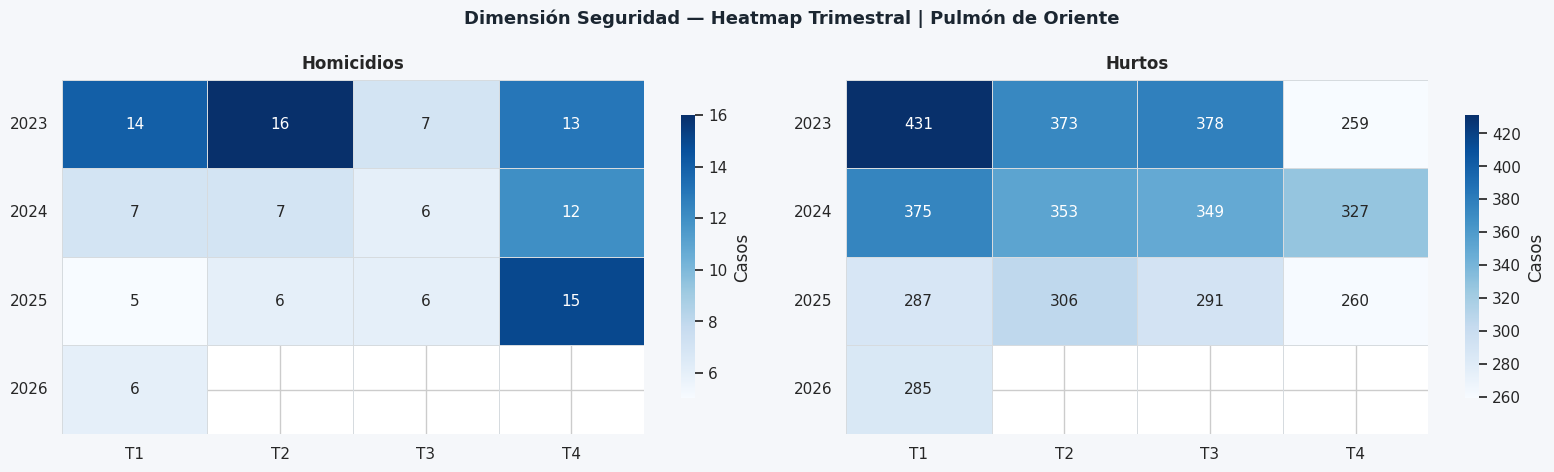

Conteo trimestral de homicidios:


,ano,trimestre,casos
0,2023,T1,14
1,2023,T2,16
2,2023,T3,7
3,2023,T4,13
4,2024,T1,7
5,2024,T2,7
6,2024,T3,6
7,2024,T4,12
8,2025,T1,5
9,2025,T2,6



Matriz homicidios:


trimestre,T1,T2,T3,T4
ano,,,,
2023,14.0,16.0,7.0,13.0
2024,7.0,7.0,6.0,12.0
2025,5.0,6.0,6.0,15.0
2026,6.0,NaN,NaN,NaN



Conteo trimestral de hurtos:


,ano,trimestre,casos
0,2023,T1,431
1,2023,T2,373
2,2023,T3,378
3,2023,T4,259
4,2024,T1,375
5,2024,T2,353
6,2024,T3,349
7,2024,T4,327
8,2025,T1,287
9,2025,T2,306



Matriz hurtos:


trimestre,T1,T2,T3,T4
ano,,,,
2023,431.0,373.0,378.0,259.0
2024,375.0,353.0,349.0,327.0
2025,287.0,306.0,291.0,260.0
2026,285.0,NaN,NaN,NaN


In [24]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

BG = "#F5F7FA"

def preparar_anio_trimestre(gdf, fecha_cols, ano_cols=None, mes_cols=None):
    """
    Prepara año, mes y trimestre desde columnas de fecha o columnas separadas.
    """

    df = gdf.copy()

    fecha_col = pick_col(df, fecha_cols, requerido=False)

    if fecha_col is not None:
        df["fecha_tmp"] = pd.to_datetime(
            df[fecha_col],
            errors="coerce",
            dayfirst=True
        )
        df["ano_tmp"] = df["fecha_tmp"].dt.year
        df["mes_tmp"] = df["fecha_tmp"].dt.month
    else:
        df["fecha_tmp"] = pd.NaT
        df["ano_tmp"] = np.nan
        df["mes_tmp"] = np.nan

    # Respaldo con columna de año si existe
    if ano_cols:
        ano_col = pick_col(df, ano_cols, requerido=False)

        if ano_col is not None:
            ano_num = pd.to_numeric(
                df[ano_col].astype(str).str.replace(",", ".", regex=False),
                errors="coerce"
            )
            df.loc[ano_num.notna(), "ano_tmp"] = ano_num[ano_num.notna()].astype(int)

    # Respaldo con columna de mes si existe
    if mes_cols:
        mes_col = pick_col(df, mes_cols, requerido=False)

        if mes_col is not None:
            mes_num = pd.to_numeric(
                df[mes_col].astype(str).str.replace(",", ".", regex=False),
                errors="coerce"
            )
            df.loc[mes_num.notna(), "mes_tmp"] = mes_num[mes_num.notna()].astype(int)

    df = df[df["ano_tmp"].notna()].copy()
    df = df[df["mes_tmp"].notna()].copy()

    df["ano"] = df["ano_tmp"].astype(int)
    df["mes"] = df["mes_tmp"].astype(int)

    # Mantener solo meses válidos
    df = df[df["mes"].between(1, 12)].copy()

    # Crear trimestre sin usar np.select para evitar error de tipos
    df["trimestre"] = "T" + (((df["mes"] - 1) // 3) + 1).astype(str)

    return df


def contar_eventos_trimestrales(gdf, fecha_cols, ano_cols=None, mes_cols=None, anios=None):
    """
    Cuenta eventos por año y trimestre.
    """

    df = preparar_anio_trimestre(
        gdf,
        fecha_cols=fecha_cols,
        ano_cols=ano_cols,
        mes_cols=mes_cols
    )

    if anios is not None:
        df = df[df["ano"].isin(anios)].copy()

    conteo = (
        df.groupby(["ano", "trimestre"])
        .size()
        .reset_index(name="casos")
    )

    base = pd.MultiIndex.from_product(
        [anios, ["T1", "T2", "T3", "T4"]],
        names=["ano", "trimestre"]
    ).to_frame(index=False)

    conteo = base.merge(
        conteo,
        on=["ano", "trimestre"],
        how="left"
    )

    conteo["casos"] = conteo["casos"].fillna(0).astype(int)

    return conteo


def crear_pivot_trimestral(conteo, anios=None, ocultar_trimestres_futuros_2026=True):
    """
    Crea matriz año x trimestre.
    Para 2026 deja T2, T3 y T4 en blanco porque la salida actual es parcial T1.
    """

    pivot = conteo.pivot_table(
        index="ano",
        columns="trimestre",
        values="casos",
        aggfunc="sum",
        fill_value=0
    )

    pivot = pivot.reindex(
        index=anios,
        columns=["T1", "T2", "T3", "T4"]
    )

    # Convertir a float para permitir NaN en 2026 T2-T4
    pivot = pivot.astype(float)

    if ocultar_trimestres_futuros_2026 and 2026 in pivot.index:
        pivot.loc[2026, ["T2", "T3", "T4"]] = np.nan

    return pivot


# ============================================================
# Homicidios por año y trimestre
# ============================================================

conteo_homicidios_trim = contar_eventos_trimestrales(
    gdf_homicidios,
    fecha_cols=["fechah", "fecha_hech", "fecha_hecho", "fecha", "fechao"],
    ano_cols=["anio", "ano", "año"],
    mes_cols=["mes", "mes_num", "month"],
    anios=ANIOS_SERIE
)

pivot_homicidios = crear_pivot_trimestral(
    conteo_homicidios_trim,
    anios=ANIOS_SERIE,
    ocultar_trimestres_futuros_2026=True
)


# ============================================================
# Hurtos por año y trimestre
# ============================================================

conteo_hurtos_trim = contar_eventos_trimestrales(
    gdf_hurtos,
    fecha_cols=["fecha_hech", "fecha_hecho", "fecha", "fechah", "fechao"],
    ano_cols=["anio", "ano", "año"],
    mes_cols=["mes", "mes_num", "month"],
    anios=ANIOS_SERIE
)

pivot_hurtos = crear_pivot_trimestral(
    conteo_hurtos_trim,
    anios=ANIOS_SERIE,
    ocultar_trimestres_futuros_2026=True
)


# ============================================================
# Gráfico: dos heatmaps separados
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 4.8), facecolor=BG)

fig.suptitle(
    "Dimensión Seguridad — Heatmap Trimestral | Pulmón de Oriente",
    fontsize=13,
    fontweight="bold",
    color="#1B2631"
)

for ax, pivot, titulo in [
    (axes[0], pivot_homicidios, "Homicidios"),
    (axes[1], pivot_hurtos, "Hurtos")
]:

    mask = pivot.isna()

    annot = pivot.copy()
    annot = annot.applymap(lambda x: "" if pd.isna(x) else f"{int(x)}")

    sns.heatmap(
        pivot,
        annot=annot,
        fmt="",
        cmap="Blues",
        linewidths=0.5,
        linecolor="#D6DBDF",
        cbar=True,
        mask=mask,
        ax=ax,
        annot_kws={"size": 11},
        cbar_kws={
            "label": "Casos",
            "shrink": 0.8
        }
    )

    ax.set_title(titulo, fontweight="bold", pad=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=0)
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout()

plt.savefig(
    "itt_pulmon_oriente_heatmap_seguridad_trimestral.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=BG
)

plt.show()


# ============================================================
# Tablas de control
# ============================================================

print("Conteo trimestral de homicidios:")
display(conteo_homicidios_trim)

print("\nMatriz homicidios:")
display(pivot_homicidios)

print("\nConteo trimestral de hurtos:")
display(conteo_hurtos_trim)

print("\nMatriz hurtos:")
display(pivot_hurtos)

## Celda 10 - Soporte historico trimestral


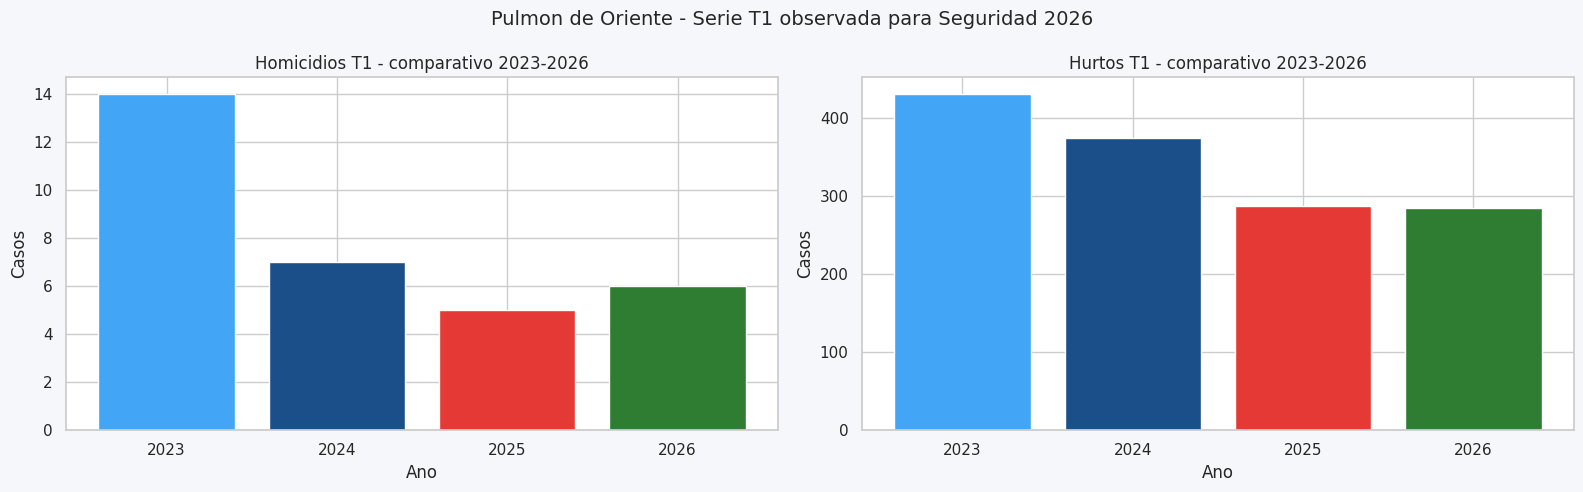

In [25]:
hom_plot = soporte_homicidios.copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor=BG)

axes[0].bar(hom_plot['ano'].astype(str), hom_plot['homicidios_t1'], color=[COLORS.get(int(a), COL_2026) for a in hom_plot['ano']])
axes[0].set_title('Homicidios T1 - comparativo 2023-2026')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Casos')

axes[1].bar(soporte_hurtos['ano'].astype(str), soporte_hurtos['hurtos_t1'], color=[COLORS.get(int(a), COL_2026) for a in soporte_hurtos['ano']])
axes[1].set_title('Hurtos T1 - comparativo 2023-2026')
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('Casos')

plt.suptitle('Pulmon de Oriente - Serie T1 observada para Seguridad 2026', fontsize=14)
plt.tight_layout()
plt.show()


## Celda 11 - Exportar a Excel


In [ ]:
meta = pd.DataFrame([
    {'campo': 'zona', 'valor': 'Pulmon de Oriente'},
    {'campo': 'alcance', 'valor': 'Dimension Seguridad T1 2026'},
    {'campo': 'unidad_analisis', 'valor': 'Zona agregada'},
    {'campo': 'corte_principal', 'valor': 'Primer trimestre de 2026'},
    {'campo': 'homicidios_2026', 'valor': 'Dato observado filtrado espacialmente a Pulmon de Oriente'},
    {'campo': 'hurtos_2026', 'valor': 'Dato observado filtrado espacialmente a Pulmon de Oriente'},
    {'campo': 'archivo_homicidios', 'valor': 'DATIC_homicidios_2023_2026T1_Pulmon_O.geojson'},
    {'campo': 'archivo_hurtos', 'valor': 'DATIC_hurtos_2023_2026T1_Pulmon_O.geojson'},
    {'campo': 'refs_homicidios_t1', 'valor': '15.0 a 30.0'},
    {'campo': 'refs_hurtos_t1', 'valor': '250.0 a 1300.0'},
])

with pd.ExcelWriter(EXPORT_PATH, engine='openpyxl') as writer:
    soporte_homicidios.to_excel(writer, sheet_name='soporte_homicidios', index=False)
    soporte_hurtos.to_excel(writer, sheet_name='soporte_hurtos', index=False)
    resultado_2026.round(2).to_excel(writer, sheet_name='seguridad_t1_2026', index=False)
    meta.to_excel(writer, sheet_name='metodologia', index=False)

print(f'Archivo exportado: {EXPORT_PATH}')
